In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

plt.style.use("default")
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white"})

topography = xr.open_dataset(
    Path("C:/Users/alfon/PycharmProjects/Sistema-deteccion-incendios/data/processed/topography_test.nc")
)

legacy_aspect_names = {
    **{f"aspect_{index}": f"aspect_{start:03d}_{end:03d}" for index, (start, end) in enumerate([(0, 45), (45, 90), (90, 135), (135, 180), (180, 225), (225, 270), (270, 315), (315, 360)], start=1)},
    "aspect_NODATA": "aspect_sin_datos",
}
topography = topography.rename({old: new for old, new in legacy_aspect_names.items() if old in topography})

print(topography)

<xarray.Dataset> Size: 3MB
Dimensions:           (y: 225, x: 203)
Coordinates:
  * y                 (y) float64 2kB 2.245e+06 2.246e+06 ... 2.469e+06
  * x                 (x) float64 2kB 2.76e+06 2.761e+06 ... 2.961e+06 2.962e+06
Data variables: (12/16)
    is_galicia        (y, x) uint8 46kB ...
    elevation_mean    (y, x) float32 183kB ...
    elevation_std     (y, x) float32 183kB ...
    slope_mean        (y, x) float32 183kB ...
    slope_std         (y, x) float32 183kB ...
    roughness_mean    (y, x) float32 183kB ...
    ...                ...
    aspect_135_180    (y, x) float32 183kB ...
    aspect_180_225    (y, x) float32 183kB ...
    aspect_225_270    (y, x) float32 183kB ...
    aspect_270_315    (y, x) float32 183kB ...
    aspect_315_360    (y, x) float32 183kB ...
    aspect_sin_datos  (y, x) float32 183kB ...
Attributes:
    title:               Topographic variables
    description:         Topographic variables aggregated to the 1 km spatial...
    module:     

In [10]:
aspect_variables = [
    f"aspect_{start:03d}_{end:03d}"
    for start, end in [(0, 45), (45, 90), (90, 135), (135, 180), (180, 225), (225, 270), (270, 315), (315, 360)]
]

aspect_total = sum(topography[variable] for variable in aspect_variables)
aspect_total = aspect_total + topography["aspect_sin_datos"]

land = topography["is_galicia"].astype(bool)
error = np.abs(aspect_total.where(land) - 1)

print("Error máximo:", float(error.max(skipna=True)))
print("Error medio:", float(error.mean(skipna=True)))

Error máximo: 1.7881393432617188e-07
Error medio: 1.5814833886906854e-08


# Prueba visual de topografía

Este notebook verifica que las variables topográficas están alineadas con la malla regular de Galicia en EPSG:3035.

In [11]:
import pandas as pd

land = topography["is_galicia"].astype(bool)
topography_variables = [
    "elevation_mean", "elevation_std",
    "slope_mean", "slope_std",
    "roughness_mean", "roughness_std",
]

print(f"Dimensiones del cubo: y={topography.sizes['y']}, x={topography.sizes['x']}")
print(f"Celdas dentro de Galicia: {int(land.sum()):,}")
print(f"CRS: {topography.attrs['crs']}")

summary = pd.DataFrame({
    variable: {
        "mínimo": float(topography[variable].where(land).min(skipna=True)),
        "media": float(topography[variable].where(land).mean(skipna=True)),
        "máximo": float(topography[variable].where(land).max(skipna=True)),
        "nulos": int(topography[variable].where(land).isnull().sum()),
    }
    for variable in topography_variables
}).T

display(summary.round(3))

Dimensiones del cubo: y=225, x=203
Celdas dentro de Galicia: 29,601
CRS: EPSG:3035


,mínimo,media,máximo,nulos
elevation_mean,0.0,504.427,1971.928,16074.0
elevation_std,0.0,35.332,195.678,16074.0
slope_mean,0.0,10.539,34.548,16074.0
slope_std,0.0,4.905,18.952,16074.0
roughness_mean,0.0,4.744,17.469,16074.0
roughness_std,0.0,2.126,11.133,16074.0


## Mapas de elevación, pendiente y rugosidad

Los mapas usan percentiles robustos para que los valores extremos no oculten el patrón espacial.

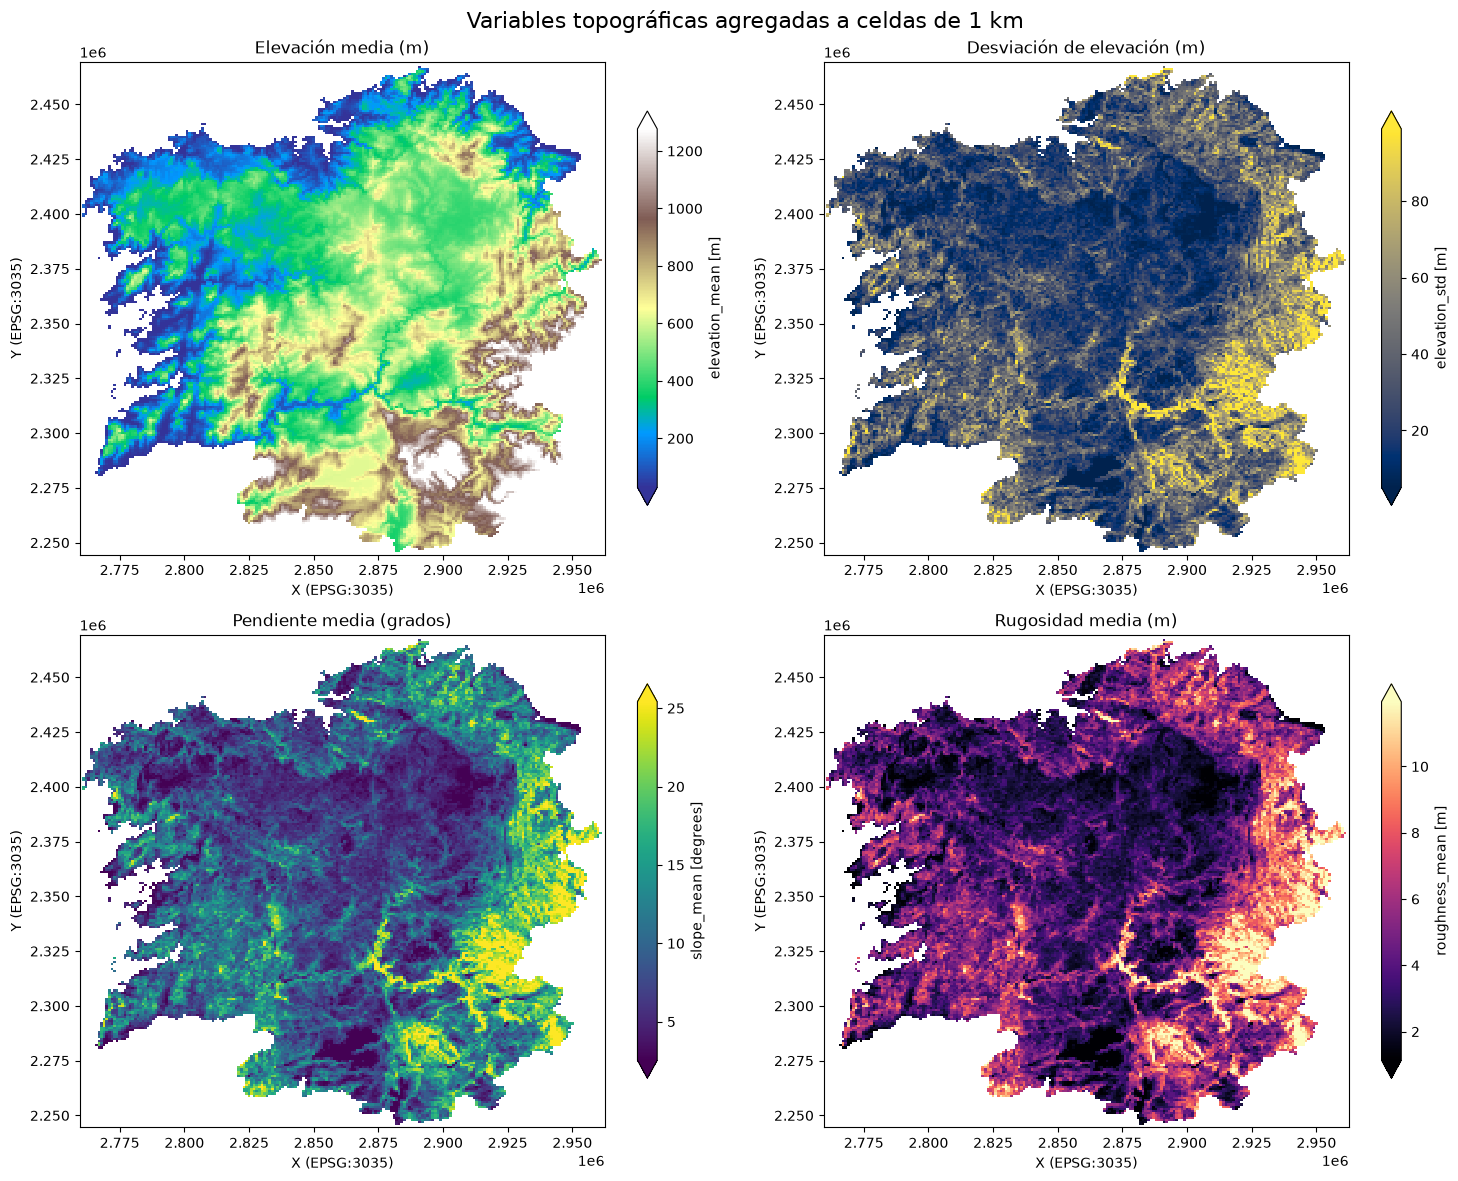

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12), facecolor="white")

plots = [
    ("elevation_mean", "terrain", "Elevación media (m)"),
    ("elevation_std", "cividis", "Desviación de elevación (m)"),
    ("slope_mean", "viridis", "Pendiente media (grados)"),
    ("roughness_mean", "magma", "Rugosidad media (m)"),
]

for axis, (variable, cmap, title) in zip(axes.flat, plots):
    axis.set_facecolor("white")
    topography[variable].where(land).plot(
        ax=axis,
        cmap=cmap,
        robust=True,
        cbar_kwargs={"shrink": 0.8},
    )
    axis.set_title(title)
    axis.set_xlabel("X (EPSG:3035)")
    axis.set_ylabel("Y (EPSG:3035)")

fig.suptitle("Variables topográficas agregadas a celdas de 1 km", fontsize=16)
plt.tight_layout()
plt.show()

## Validación y mapas de orientación

Las ocho proporciones de orientación, nombradas por su intervalo angular, y `aspect_sin_datos` deben sumar uno en cada celda terrestre.

Error máximo de cierre: 1.79e-07
Error medio de cierre: 1.58e-08


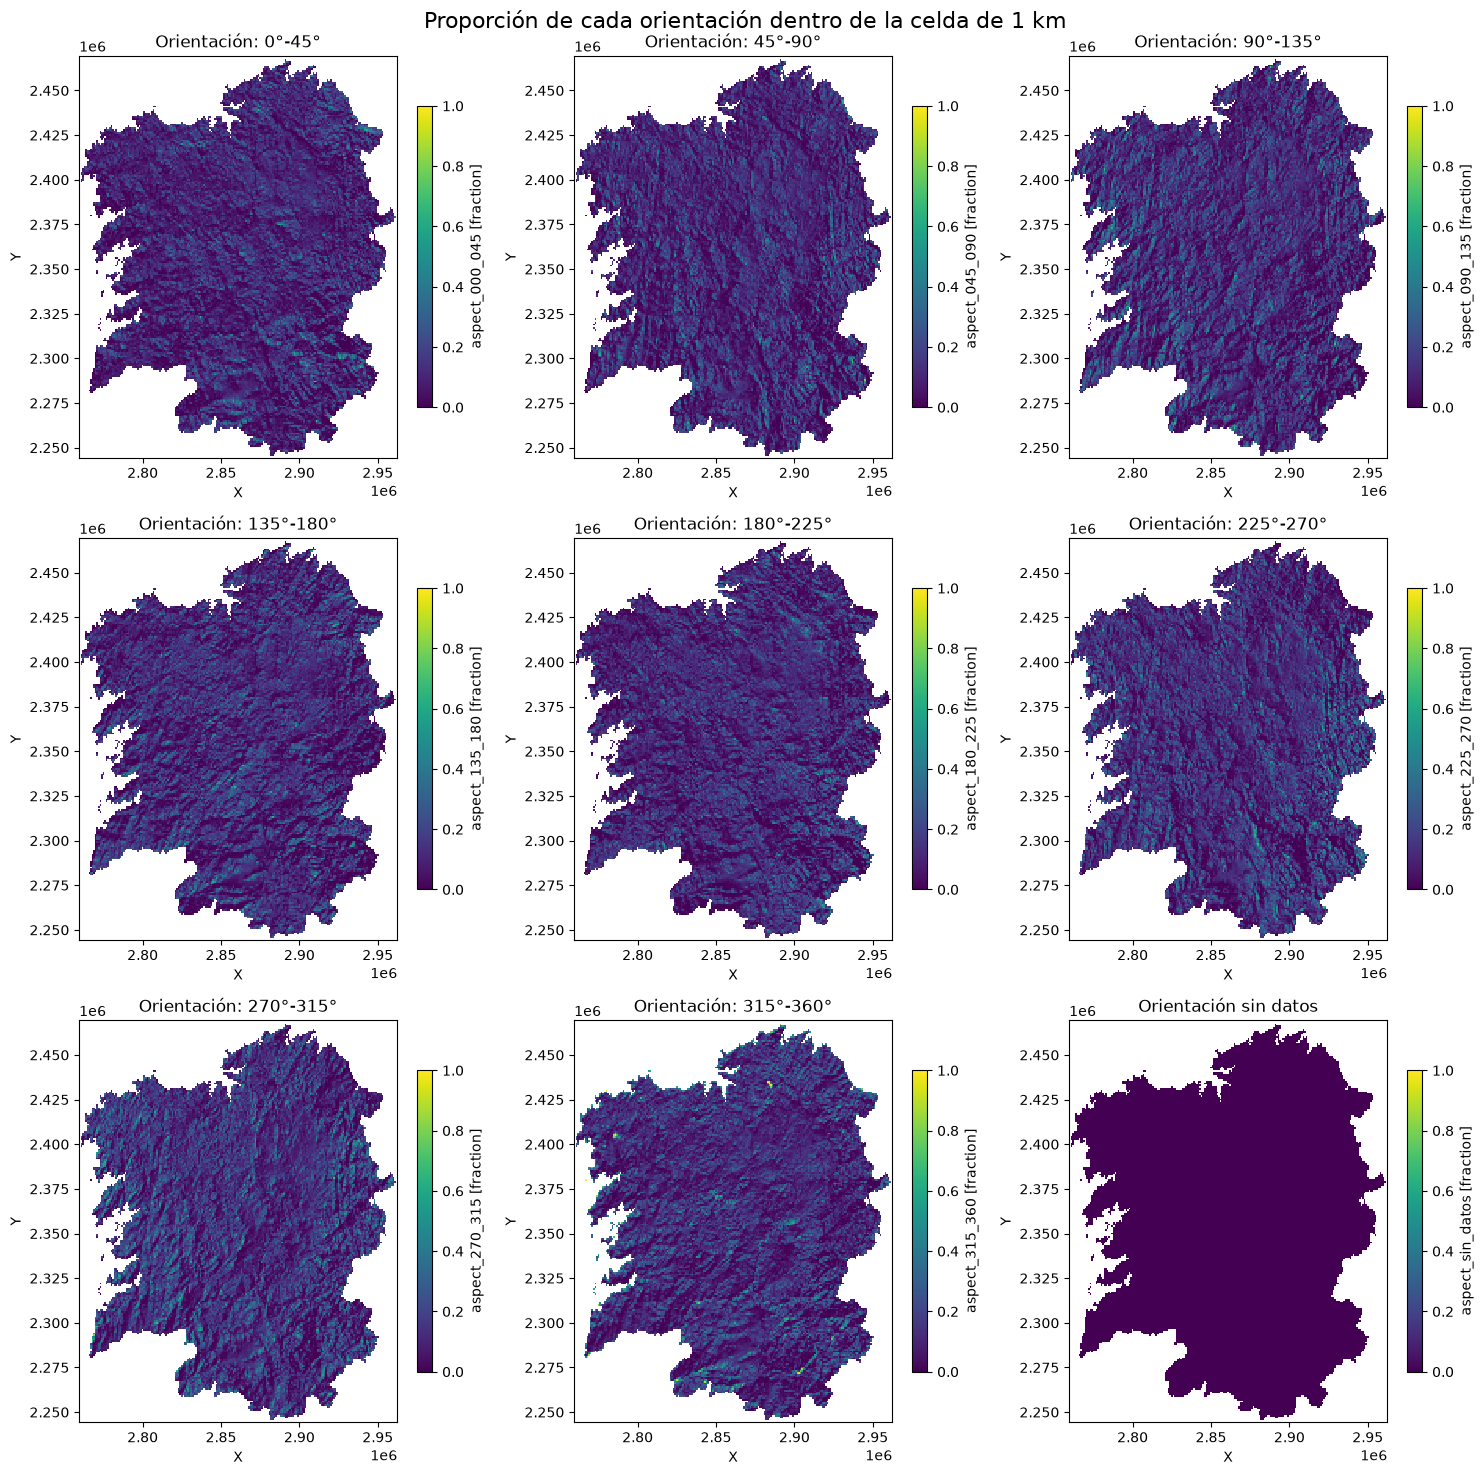

In [13]:
aspect_variables = [
    f"aspect_{start:03d}_{end:03d}"
    for start, end in [(0, 45), (45, 90), (90, 135), (135, 180), (180, 225), (225, 270), (270, 315), (315, 360)]
]
aspect_total = sum(topography[variable] for variable in aspect_variables)
aspect_total = aspect_total + topography["aspect_sin_datos"]
aspect_error = np.abs(aspect_total.where(land) - 1)

print(f"Error máximo de cierre: {float(aspect_error.max(skipna=True)):.2e}")
print(f"Error medio de cierre: {float(aspect_error.mean(skipna=True)):.2e}")

aspect_labels = {
    **{variable: f"Orientación: {start}°-{end}°" for variable, (start, end) in zip(aspect_variables, [(0, 45), (45, 90), (90, 135), (135, 180), (180, 225), (225, 270), (270, 315), (315, 360)])},
    "aspect_sin_datos": "Orientación sin datos",
}

fig, axes = plt.subplots(3, 3, figsize=(15, 15), facecolor="white")
for axis, variable in zip(axes.flat, [*aspect_variables, "aspect_sin_datos"]):
    axis.set_facecolor("white")
    topography[variable].where(land).plot(
        ax=axis,
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar_kwargs={"shrink": 0.75},
    )
    axis.set_title(aspect_labels[variable])
    axis.set_xlabel("X")
    axis.set_ylabel("Y")

fig.suptitle("Proporción de cada orientación dentro de la celda de 1 km", fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
print("Prueba completada correctamente si:")
print("- Los mapas solo muestran valores dentro de Galicia.")
print("- Elevación, pendiente y rugosidad tienen patrones espaciales coherentes.")
print("- El error de cierre de orientación es cercano a cero.")
print("- No aparecen valores nulos inesperados dentro de Galicia.")

Prueba completada correctamente si:
- Los mapas solo muestran valores dentro de Galicia.
- Elevación, pendiente y rugosidad tienen patrones espaciales coherentes.
- El error de cierre de orientación es cercano a cero.
- No aparecen valores nulos inesperados dentro de Galicia.
